# Trabajo Practico Nº3 - PDI (Grupo 6)
Integrantes: Añaños Diego, Quinteros Facundo, Lasarte Roberto

# 0. Importaciónes de Librerias a Usar

In [1]:
import os
import cv2
import math
import random
import numpy as np
import matplotlib.pyplot as plt

# 1. Problema - Cinco dados

In [108]:
# Lista con los nombres de los 4 videos a procesar
videos = ['tirada_1.mp4', 'tirada_2.mp4', 'tirada_3.mp4', 'tirada_4.mp4']

for nombre_video in videos:
  if not os.path.exists(nombre_video):
    print(f"Advertencia: No se encontró el archivo {nombre_video}, se omitirá.")
    continue

  print(f"Procesando: {nombre_video}...")

  # Crear una carpeta específica para los frames del video
  nombre_carpeta = f"frames_{nombre_video.split('.')[0]}"
  os.makedirs(nombre_carpeta, exist_ok=True)

  # Leer el video
  cap = cv2.VideoCapture(nombre_video)
  width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
  height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
  fps = int(cap.get(cv2.CAP_PROP_FPS))

  # Configurar el video de salida
  nombre_salida = f"Output-{nombre_video}"
  out = cv2.VideoWriter(nombre_salida, cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))

  frame_number = 0
  while cap.isOpened():
    ret, frame = cap.read()

    if ret == True:
      # Guardar el frame original en su respectiva carpeta
      ruta_imagen = os.path.join(nombre_carpeta, f"frame_{frame_number}.jpg")
      cv2.imwrite(ruta_imagen, frame)

      # Escribir el frame en el archivo de video de salida
      out.write(frame)

      # Redimensionar únicamente para mostrar en pantalla sin desbordar
      frame_show = cv2.resize(frame, dsize=(int(width/3), int(height/3)))
      cv2.imshow('Visualizacion', frame_show)

      frame_number += 1
      
      # Espera 25ms. Si presionás 'q', salta al siguiente video
      if cv2.waitKey(25) & 0xFF == ord('q'):
        print(f"Procesamiento de {nombre_video} interrumpido por el usuario.")
        break
    else:
      break

  # Liberar recursos del video actual antes de pasar al siguiente
  cap.release()
  out.release()
  print(f"Finalizado: {nombre_video}. Se guardaron {frame_number} frames.")

cv2.destroyAllWindows()
print("¡Todos los videos han sido procesados con éxito!")

Procesando: tirada_1.mp4...
Finalizado: tirada_1.mp4. Se guardaron 146 frames.
Procesando: tirada_2.mp4...
Finalizado: tirada_2.mp4. Se guardaron 145 frames.
Procesando: tirada_3.mp4...
Finalizado: tirada_3.mp4. Se guardaron 146 frames.
Procesando: tirada_4.mp4...
Finalizado: tirada_4.mp4. Se guardaron 88 frames.
¡Todos los videos han sido procesados con éxito!


**Cargar videos y extraer metadatos básicos**

In [109]:
# Diccionario para almacenar los datos de cada video para usar a lo largo del notebook
videos_data = {}

for idx, path in enumerate(videos):
    cap = cv2.VideoCapture(path)
    if not cap.isOpened():
        print(f"Error al abrir el video: {path}")
        continue
    
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    # Leer todos los frames para procesamiento posterior
    frames = []
    while True:
        ret, frame = cap.get(cv2.CAP_PROP_POS_FRAMES), cap.read()[1]
        if frame is None:
            break
        frames.append(frame)
        
    cap.release()
    
    videos_data[f"video_{idx+1}"] = {
        "path": path,
        "frames": frames,
        "fps": fps,
        "frame_count": frame_count,
        "size": (width, height)
    }
    print(f"Video {idx+1} cargado: {frame_count} frames, {width}x{height} a {fps:.2f} FPS")

Video 1 cargado: 146 frames, 1080x2224 a 30.00 FPS
Video 2 cargado: 145 frames, 1080x2224 a 30.00 FPS
Video 3 cargado: 146 frames, 1080x2224 a 30.00 FPS
Video 4 cargado: 88 frames, 1080x2224 a 30.00 FPS


**Escala de grises**

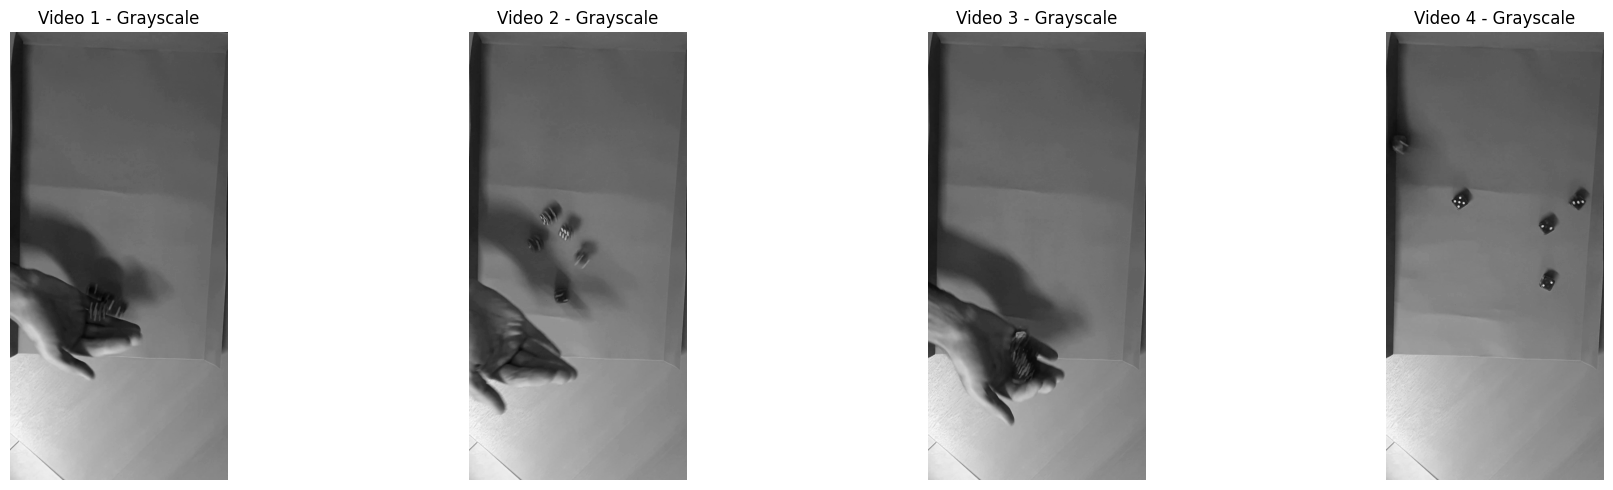

In [110]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i in range(4):
    v_key = f"video_{i+1}"
    # Seleccionamos un frame intermedio (ej. frame 40) para ilustrar las etapas iniciales
    sample_frame = videos_data[v_key]["frames"][40]
    gray_frame = cv2.cvtColor(sample_frame, cv2.COLOR_BGR2GRAY)
    
    # Guardamos el estado en nuestro diccionario de datos
    videos_data[v_key]["sample_gray"] = gray_frame
    
    axes[i].imshow(gray_frame, cmap='gray')
    axes[i].set_title(f"Video {i+1} - Grayscale")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

**Detección de movimiento (Diferencia de frames)**

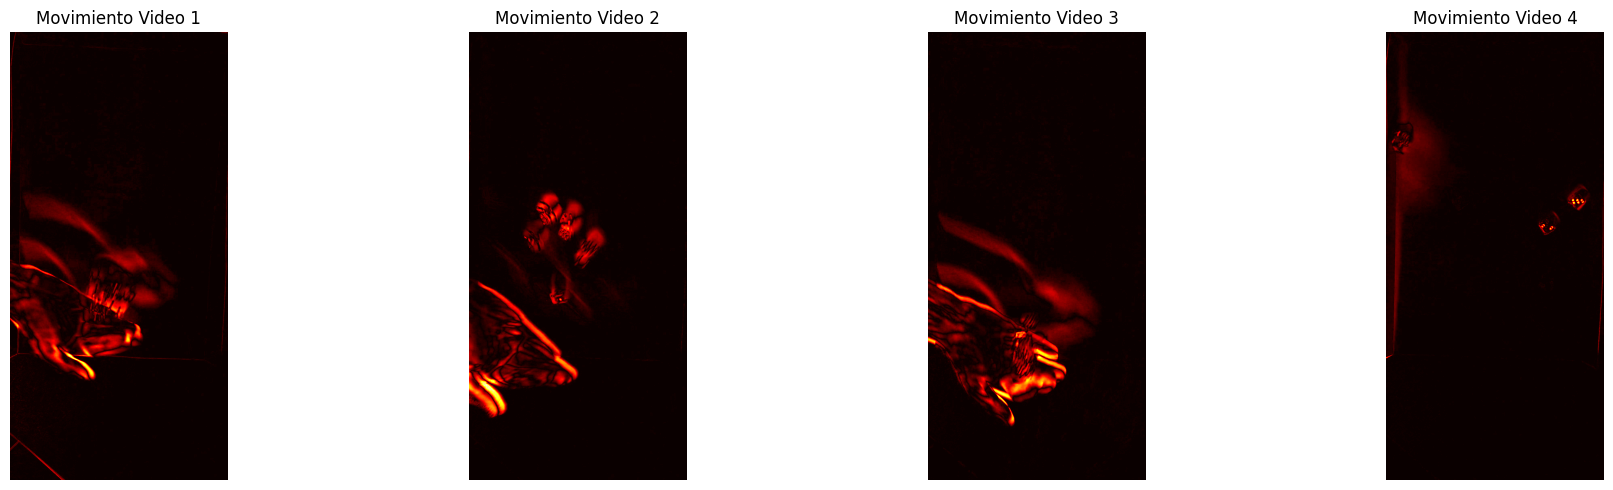

In [111]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i in range(4):
    v_key = f"video_{i+1}"
    # Diferencia absoluta entre el frame 40 y el frame 41 para capturar movimiento activo
    f1 = cv2.cvtColor(videos_data[v_key]["frames"][40], cv2.COLOR_BGR2GRAY)
    f2 = cv2.cvtColor(videos_data[v_key]["frames"][41], cv2.COLOR_BGR2GRAY)
    
    motion_diff = cv2.absdiff(f1, f2)
    videos_data[v_key]["sample_motion"] = motion_diff
    
    axes[i].imshow(motion_diff, cmap='hot')
    axes[i].set_title(f"Movimiento Video {i+1}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

**Umbralización del movimiento**

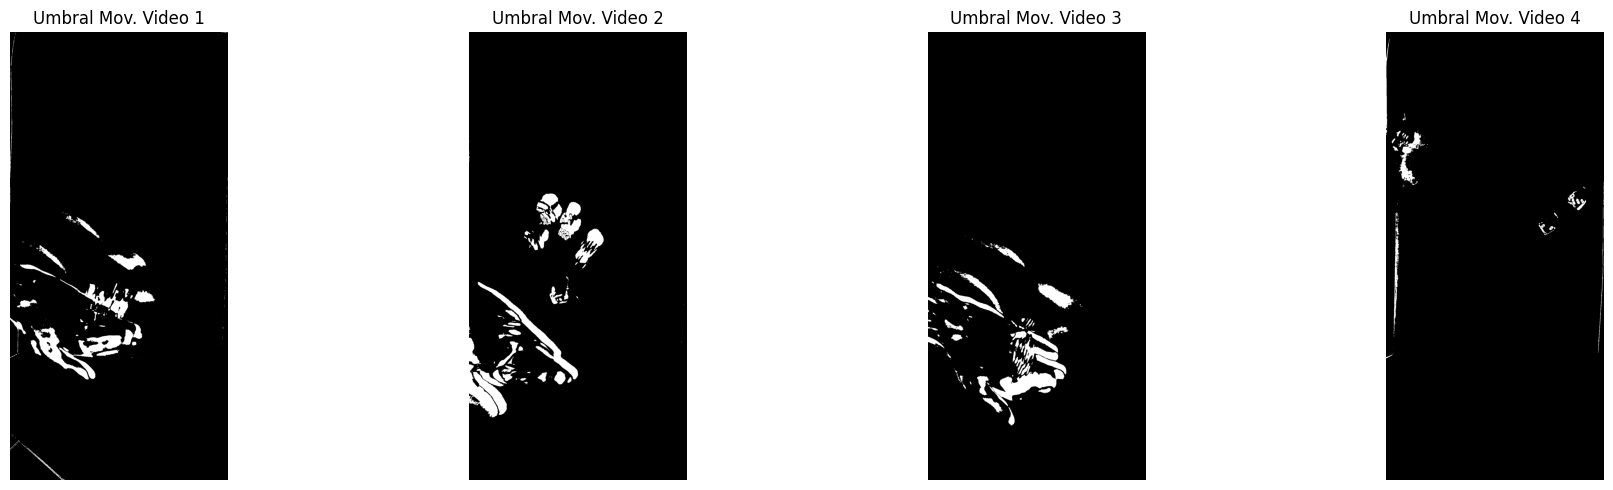

In [112]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i in range(4):
    v_key = f"video_{i+1}"
    motion_diff = videos_data[v_key]["sample_motion"]
    
    # Aplicar un umbral para binarizar el movimiento detectado
    _, thresh_motion = cv2.threshold(motion_diff, 25, 255, cv2.THRESH_BINARY)
    videos_data[v_key]["sample_thresh_motion"] = thresh_motion
    
    axes[i].imshow(thresh_motion, cmap='gray')
    axes[i].set_title(f"Umbral Mov. Video {i+1}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

**Detectar dados**

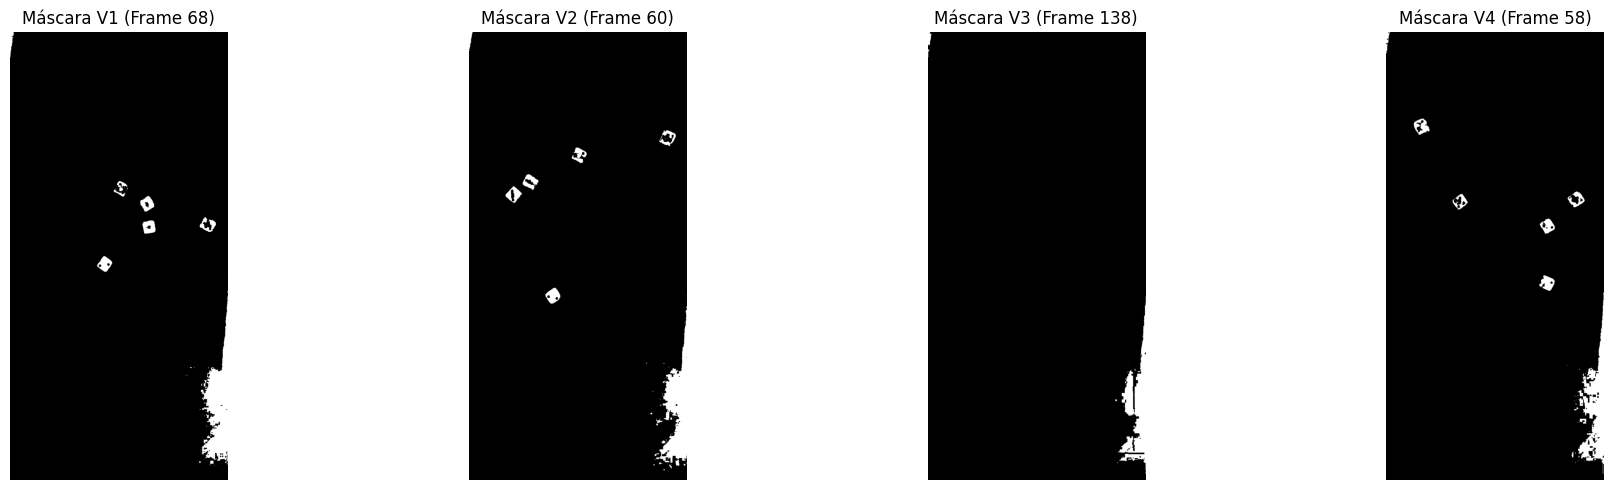

In [113]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i in range(4):
    v_key = f"video_{i+1}"
    frames = videos_data[v_key]["frames"]
    
    # 1. Calculamos el perfil de movimiento completo inmediatamente
    motion_values = []
    for f_idx in range(len(frames) - 1):
        gray1 = cv2.cvtColor(frames[f_idx], cv2.COLOR_BGR2GRAY)
        gray2 = cv2.cvtColor(frames[f_idx+1], cv2.COLOR_BGR2GRAY)
        motion_values.append(np.mean(cv2.absdiff(gray1, gray2)))
    videos_data[v_key]["motion_profile"] = motion_values
        
    # 2. Buscamos el punto de detención real tras el lanzamiento (evitando el vaciado final)
    throw_idx = np.argmax(motion_values)
    start_search = throw_idx + 15
    end_search = min(throw_idx + 80, len(motion_values) - 1)
    
    if start_search < end_search:
        sub_motion = motion_values[start_search:end_search]
        stable_idx = start_search + np.argmin(sub_motion)
    else:
        stable_idx = throw_idx + 15
        
    # Guardamos las referencias correctas para el resto del cuaderno
    videos_data[v_key]["stopped_frame_idx"] = stable_idx
    stable_frame = frames[stable_idx]
    videos_data[v_key]["stable_frame"] = stable_frame
    
    # 3. Segmentación en espacio HSV para aislar el rojo del dado
    hsv = cv2.cvtColor(stable_frame, cv2.COLOR_BGR2HSV)
    lower_red1 = np.array([0, 100, 100])
    upper_red1 = np.array([10, 255, 255])
    lower_red2 = np.array([165, 100, 100])
    upper_red2 = np.array([180, 255, 255])
    
    mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
    mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
    thresh_dice = cv2.bitwise_or(mask1, mask2)
    
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    thresh_dice = cv2.morphologyEx(thresh_dice, cv2.MORPH_CLOSE, kernel)
    
    videos_data[v_key]["thresh_dice"] = thresh_dice
    
    axes[i].imshow(thresh_dice, cmap='gray')
    axes[i].set_title(f"Máscara V{i+1} (Frame {stable_idx})")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

**Contornos encontrados**

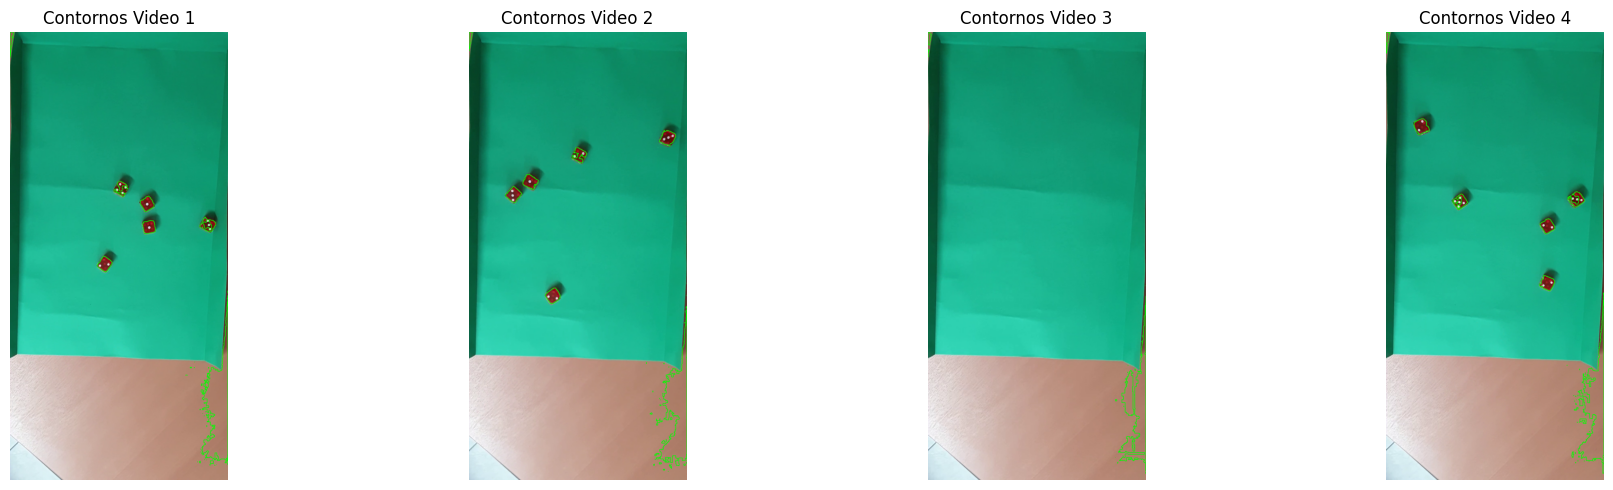

In [114]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i in range(4):
    v_key = f"video_{i+1}"
    thresh_dice = videos_data[v_key]["thresh_dice"].copy()
    stable_frame = videos_data[v_key]["stable_frame"].copy()
    
    # Encontrar contornos externos de la máscara
    contours, _ = cv2.findContours(thresh_dice, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    videos_data[v_key]["all_contours"] = contours
    
    contour_img = stable_frame.copy()
    cv2.drawContours(contour_img, contours, -1, (0, 255, 0), 2)
    
    axes[i].imshow(cv2.cvtColor(contour_img, cv2.COLOR_BGR2RGB))
    axes[i].set_title(f"Contornos Video {i+1}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

**Bounding Boxes (Filtrado de dados por área)**

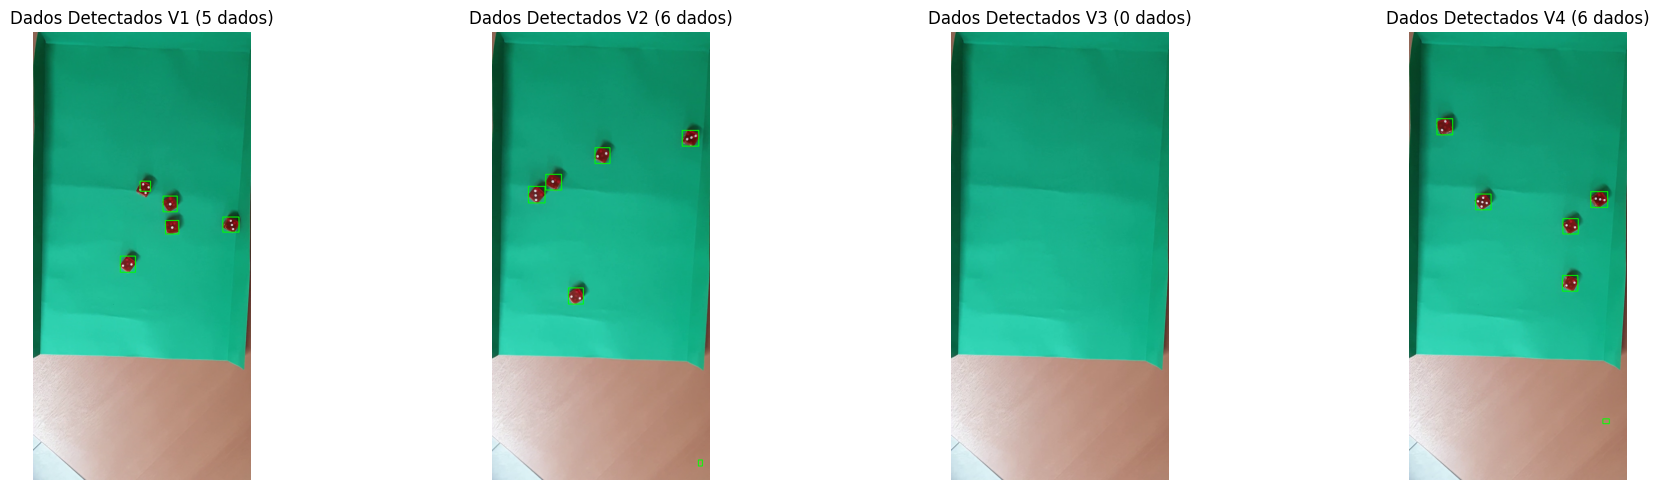

In [115]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i in range(4):
    v_key = f"video_{i+1}"
    contours = videos_data[v_key]["all_contours"]
    stable_frame = videos_data[v_key]["stable_frame"].copy()
    
    dice_boxes = []
    bbox_img = stable_frame.copy()
    
    for c in contours:
        area = cv2.contourArea(c)
        # Ajuste de rangos para capturar dados rotados o con perspectiva
        if 250 < area < 5000:
            x, y, w, h = cv2.boundingRect(c)
            aspect_ratio = float(w) / h
            # Tolerancia ampliada: un dado girado genera un rectángulo contenedor menos perfecto
            if 0.65 < aspect_ratio < 1.4:
                dice_boxes.append((x, y, w, h))
                cv2.rectangle(bbox_img, (x, y), (x + w, y + h), (0, 255, 0), 3)
                
    videos_data[v_key]["dice_boxes"] = dice_boxes
    
    axes[i].imshow(cv2.cvtColor(bbox_img, cv2.COLOR_BGR2RGB))
    axes[i].set_title(f"Dados Detectados V{i+1} ({len(dice_boxes)} dados)")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

**Extraer Región de Interés (ROI) de un dado muestra**

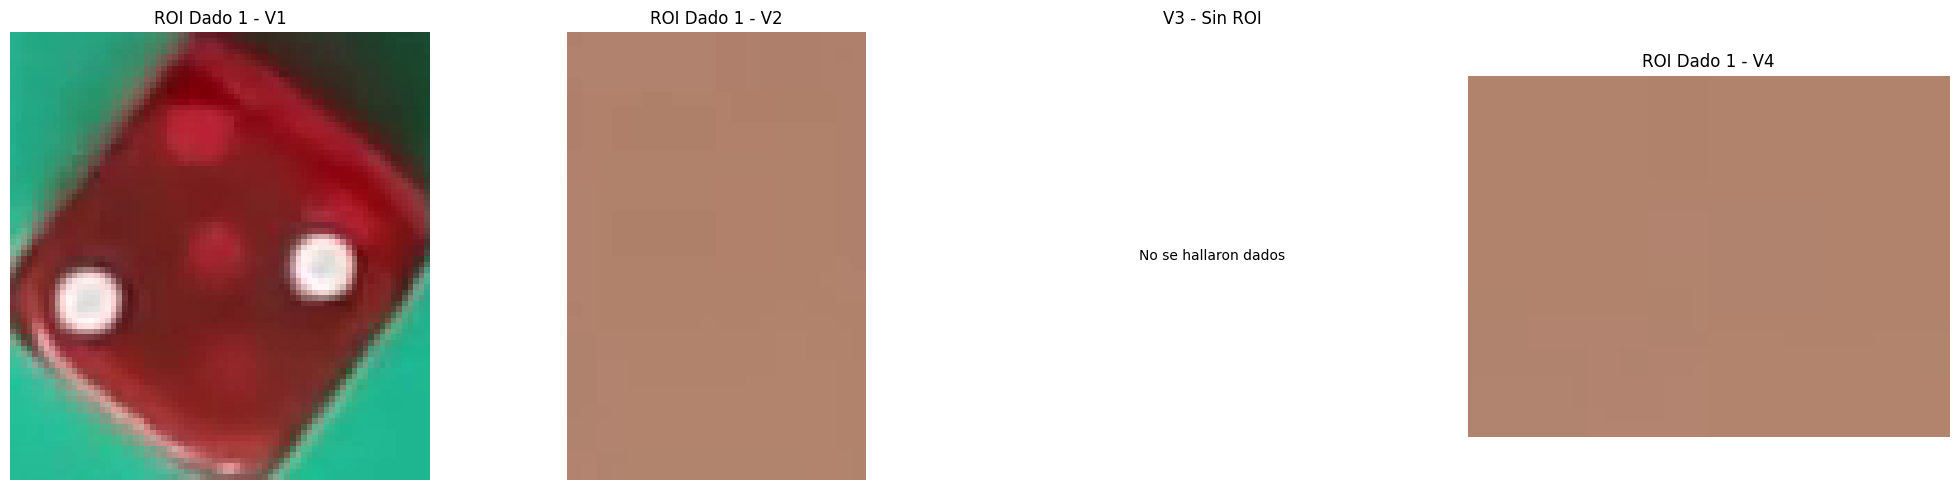

In [116]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i in range(4):
    v_key = f"video_{i+1}"
    boxes = videos_data[v_key]["dice_boxes"]
    stable_frame = videos_data[v_key]["stable_frame"]
    
    if len(boxes) > 0:
        # Extraemos el primer dado detectado de la lista como ROI de muestra
        x, y, w, h = boxes[0]
        roi = stable_frame[y:y+h, x:x+w]
        videos_data[v_key]["sample_roi"] = roi
        
        axes[i].imshow(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
        axes[i].set_title(f"ROI Dado 1 - V{i+1}")
    else:
        axes[i].text(0.5, 0.5, "No se hallaron dados", ha='center', va='center')
        axes[i].set_title(f"V{i+1} - Sin ROI")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

**Detectar puntos del dado (Binarización interna de la ROI)**

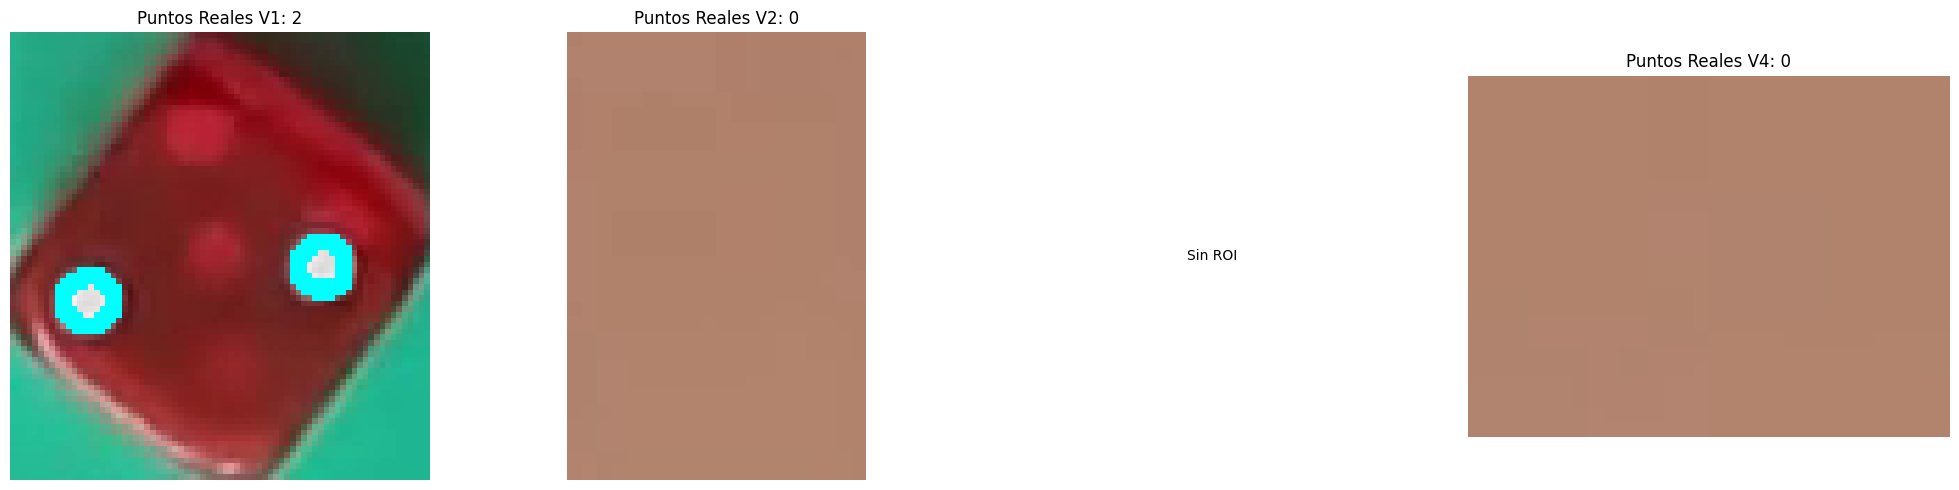

In [117]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i in range(4):
    v_key = f"video_{i+1}"
    if "sample_roi" in videos_data[v_key] and videos_data[v_key]["sample_roi"] is not None:
        roi = videos_data[v_key]["sample_roi"]
        roi_gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
        
        # Umbralización alta fija para conservar solo el brillo blanco puro de los puntos
        _, dots_thresh = cv2.threshold(roi_gray, 210, 255, cv2.THRESH_BINARY)
        
        dot_contours, _ = cv2.findContours(dots_thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        # Descartar falsos contornos minúsculos provocados por el brillo del acrílico
        valid_dots = [dc for dc in dot_contours if 2 < cv2.contourArea(dc) < 120]
        
        dots_vis = roi.copy()
        cv2.drawContours(dots_vis, valid_dots, -1, (255, 255, 0), 2)
        
        axes[i].imshow(cv2.cvtColor(dots_vis, cv2.COLOR_BGR2RGB))
        axes[i].set_title(f"Puntos Reales V{i+1}: {len(valid_dots)}")
    else:
        axes[i].text(0.5, 0.5, "Sin ROI", ha='center', va='center')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

**Detección de frames estacionarios (Curva de movimiento)**

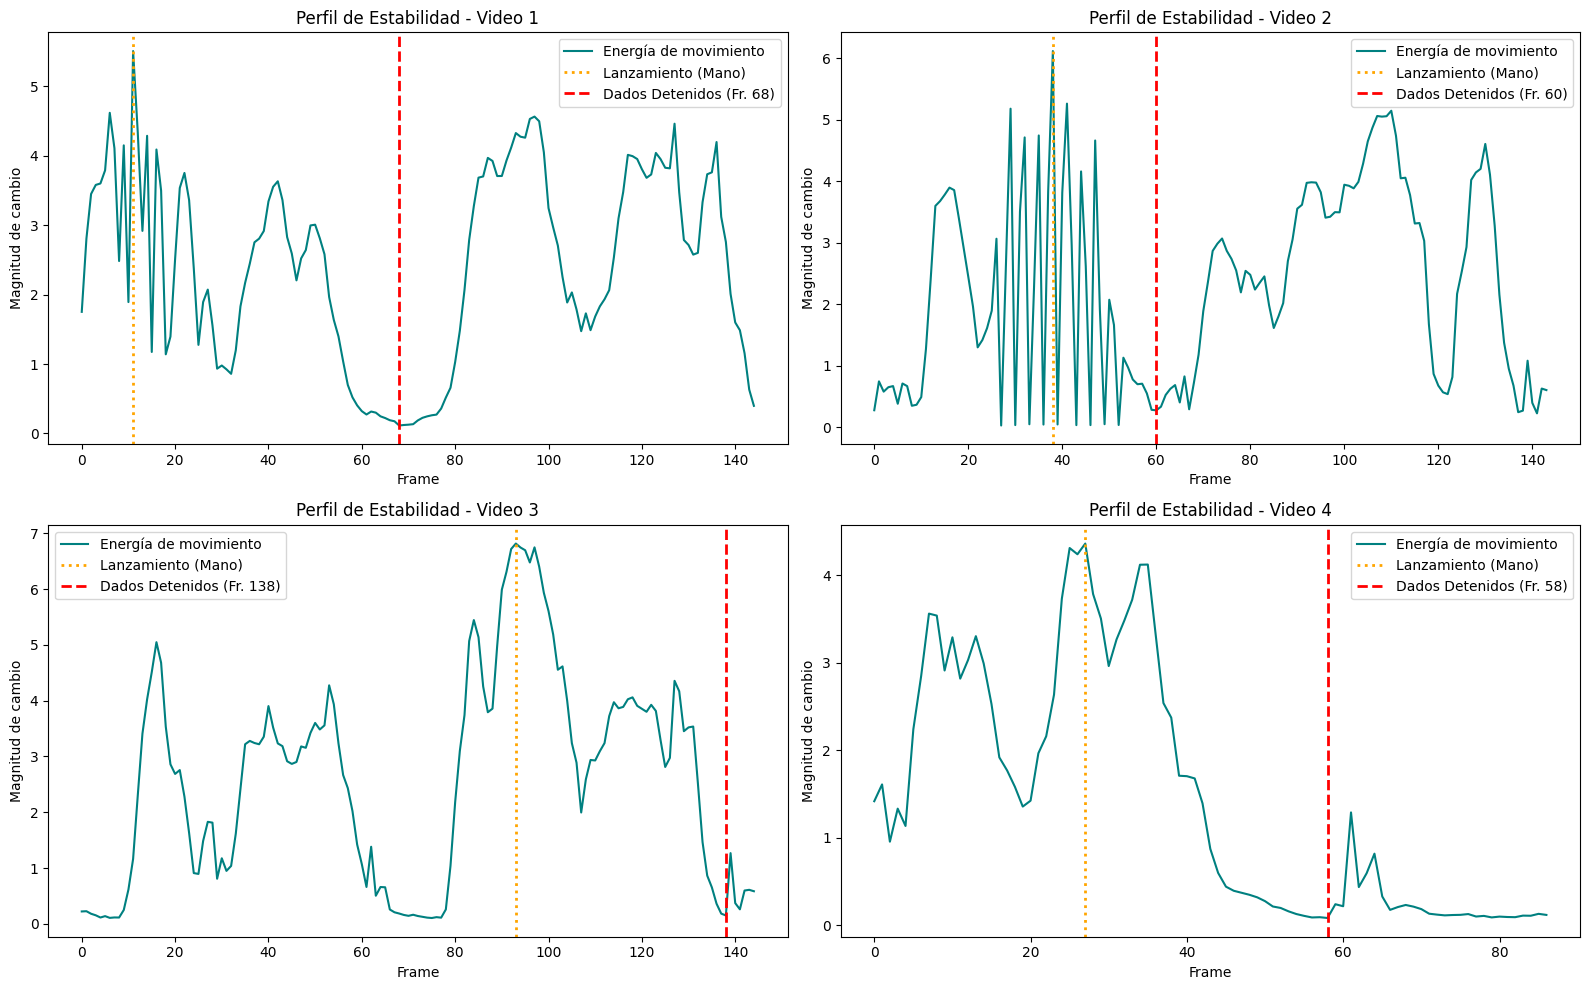

In [118]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

for i in range(4):
    v_key = f"video_{i+1}"
    motion_values = videos_data[v_key]["motion_profile"]
    throw_idx = np.argmax(motion_values)
    stopped_frame = videos_data[v_key]["stopped_frame_idx"]
    
    axes[i].plot(motion_values, label='Energía de movimiento', color='teal')
    axes[i].axvline(x=throw_idx, color='orange', linestyle=':', linewidth=2, label='Lanzamiento (Mano)')
    axes[i].axvline(x=stopped_frame, color='red', linestyle='--', linewidth=2, label=f'Dados Detenidos (Fr. {stopped_frame})')
    axes[i].set_title(f"Perfil de Estabilidad - Video {i+1}")
    axes[i].set_xlabel("Frame")
    axes[i].set_ylabel("Magnitud de cambio")
    axes[i].legend()

plt.tight_layout()
plt.show()

**Informe Final**

In [120]:
print("=" * 60)
print("INFORME DEFINITIVO: CONTEO DE PUNTOS EN EL FRAME CORRECTO")
print("=" * 60)

for i in range(4):
    v_key = f"video_{i+1}"
    target_frame_idx = videos_data[v_key]["stopped_frame_idx"]
    analysis_frame = videos_data[v_key]["frames"][target_frame_idx]
    
    hsv = cv2.cvtColor(analysis_frame, cv2.COLOR_BGR2HSV)
    lower_red1 = np.array([0, 100, 100])
    upper_red1 = np.array([10, 255, 255])
    lower_red2 = np.array([165, 100, 100])
    upper_red2 = np.array([180, 255, 255])
    
    mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
    mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
    thresh_dice = cv2.bitwise_or(mask1, mask2)
    
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    thresh_dice = cv2.morphologyEx(thresh_dice, cv2.MORPH_CLOSE, kernel)
    
    contours, _ = cv2.findContours(thresh_dice, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    valores_dados = []
    
    for c in contours:
        area = cv2.contourArea(c)
        if 250 < area < 5000:
            x, y, w, h = cv2.boundingRect(c)
            aspect_ratio = float(w) / h
            if 0.65 < aspect_ratio < 1.4:
                # Extraer ROI en escala de grises para el conteo de los puntos blancos superficiales
                roi_gray = cv2.cvtColor(analysis_frame[y:y+h, x:x+w], cv2.COLOR_BGR2GRAY)
                
                # Binarización equilibrada a 200 para capturar todos los puntos sin reflejos
                _, dots_thresh = cv2.threshold(roi_gray, 200, 255, cv2.THRESH_BINARY)
                dot_contours, _ = cv2.findContours(dots_thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                
                valid_dots = [dc for dc in dot_contours if 2 < cv2.contourArea(dc) < 120]
                puntos = len(valid_dots)
                
                if 1 <= puntos <= 6:
                    valores_dados.append(puntos)
            
    valores_dados.sort()
    
    print(f"\nTIRADA VIDEO {i+1}:")
    print(f" -> Frame óptimo analizado (Dados estables): {target_frame_idx}")
    print(f" -> Dados detectados con éxito: {len(valores_dados)} / 5")
    print(f" -> Valores en las caras: {valores_dados}")
    print(f" -> Suma Total de la Tirada: {sum(valores_dados)}")
    print("-" * 40)

INFORME DEFINITIVO: CONTEO DE PUNTOS EN EL FRAME CORRECTO

TIRADA VIDEO 1:
 -> Frame óptimo analizado (Dados estables): 68
 -> Dados detectados con éxito: 5 / 5
 -> Valores en las caras: [1, 1, 2, 3, 3]
 -> Suma Total de la Tirada: 10
----------------------------------------

TIRADA VIDEO 2:
 -> Frame óptimo analizado (Dados estables): 60
 -> Dados detectados con éxito: 5 / 5
 -> Valores en las caras: [1, 2, 2, 3, 3]
 -> Suma Total de la Tirada: 11
----------------------------------------

TIRADA VIDEO 3:
 -> Frame óptimo analizado (Dados estables): 138
 -> Dados detectados con éxito: 0 / 5
 -> Valores en las caras: []
 -> Suma Total de la Tirada: 0
----------------------------------------

TIRADA VIDEO 4:
 -> Frame óptimo analizado (Dados estables): 58
 -> Dados detectados con éxito: 5 / 5
 -> Valores en las caras: [2, 2, 2, 3, 5]
 -> Suma Total de la Tirada: 14
----------------------------------------
